# 1. Building a Machine Learning Model for Movie Revenue Prediction (01_movies_eda_cleaning_feature_prep)

### 1. Exploratory Data Analysis

This notebook currently:
- loads the cleaned movie dataset
- separates the target variable `revenue` from the input features
- removes identifier and path columns that are not useful for modeling
- parses `release_date` as a datetime feature
- separates the current features into numerical, categorical, ordinal, and nominal groups
- checks which features still contain missing values


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

try:
    from itables import show
except Exception:
    show = display

np.random.seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

candidate_paths = [
    Path('Dataset/comparison_outputs/Movies-Dataset.csv'),
    Path('Dataset/comparison_outputs/Movies-Dataset.csv'), # 16000 rows - accuracy 0.61 
    Path(r'Dataset\comparison_outputs\Movies-Dataset.csv'),
]
dataset_path = next((path for path in candidate_paths if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError('Movies-Dataset-no-missing-2000-2026.csv was not found in the expected relative or absolute locations.')

df_raw = pd.read_csv(dataset_path, encoding='utf-8-sig', low_memory=False)

columns_to_drop = [
    'id', 'poster_path', 'backdrop_path', 'original_title', 'homepage',
    'imdb_id', 'recommendations', 'merge_key', 'record_origin', 'actor_1', 'actor_2', 'actor_3',
    'actor_1_tmdb_name', 'actor_1_tmdb_id', 'actor_2_tmdb_name', 'actor_2_tmdb_id',
    'actor_3_tmdb_name', 'actor_3_tmdb_id', 'credits', 'vote_count', 'vote_average'
]
df_clean = df_raw.copy()
df_clean['revenue'] = pd.to_numeric(df_clean['revenue'], errors='coerce')
df_clean['budget'] = pd.to_numeric(df_clean['budget'], errors='coerce')

invalid_core_rows = (
    df_clean['revenue'].isna()
    | (df_clean['revenue'] <= 0)
    | df_clean['budget'].isna()
    | (df_clean['budget'] <= 0)
)

if invalid_core_rows.any():
    print(f'Removed {invalid_core_rows.sum()} rows with missing or non-positive revenue/budget before EDA.')
    display(df_clean.loc[invalid_core_rows, ['title', 'release_date', 'budget', 'revenue', 'status']].head())
    df_clean = df_clean.loc[~invalid_core_rows].copy()

X_raw = df_clean.drop(columns=['revenue']).copy()
y_raw = df_clean['revenue'].copy()

X_raw = X_raw.drop(columns=columns_to_drop, errors='ignore')
X_raw['release_date'] = pd.to_datetime(X_raw['release_date'], errors='coerce')

X = X_raw.copy()
y = y_raw.copy()

n_samples, n_features = X.shape
print(f'Dataset path: {dataset_path.resolve()}')
print(f'Raw rows loaded: {len(df_raw)}')
print(f'Rows kept after validation: {n_samples}')
print(f'(a) Number of features: {n_features}')

print('\n(b) First 10 rows of the feature set:')
display(X.head())
    
print('First 10 target values:')
display(y.head().to_frame(name='revenue'))


Removed 1 rows with missing or non-positive revenue/budget before EDA.


,title,release_date,budget,revenue,status
10122,Some Bears,2013-05-15,12.0,-12.0,Released


Dataset path: Dataset\comparison_outputs\Movies-Dataset.csv
Raw rows loaded: 16441
Rows kept after validation: 16440
(a) Number of features: 19

(b) First 10 rows of the feature set:


,title,genres,original_language,overview,popularity,production_companies,release_date,budget,runtime,status,tagline,keywords,adult,production_countries,spoken_languages,actor_1_popularity,actor_2_popularity,actor_3_popularity,mpaa_rating
0,Meg 2: The Trench,Action-Science Fiction-Horror,en,An exploratory dive into the deepest depths of...,8763.998,Apelles Entertainment-Warner Bros. Pictures-di...,2023-08-02,129000000.0,116.0,Released,Back for seconds.,based on novel or book-sequel-kaiju,0.0,"China, United States of America",English,23.2858,0.0000,1.9394,PG-13
1,The Pope's Exorcist,Horror-Mystery-Thriller,en,Father Gabriele Amorth Chief Exorcist of the V...,5953.227,Screen Gems-2.0 Entertainment-Jesus & Mary-Wor...,2023-04-05,18000000.0,103.0,Released,Inspired by the actual files of Father Gabriel...,spain-rome italy-vatican-pope-pig-possession-c...,0.0,"Spain, United Kingdom, United States of America","English, Fulah, Spanish, Latin, German, Italian",4.5537,1.1310,1.0691,R
2,Transformers: Rise of the Beasts,Action-Adventure-Science Fiction,en,When a new threat capable of destroying the en...,5409.104,Skydance-Paramount-di Bonaventura Pictures-Bay...,2023-06-06,200000000.0,127.0,Released,Unite or fall.,peru-alien-end of the world-based on cartoon-b...,0.0,United States of America,"Quechua, Spanish, English",2.2273,1.0588,2.2351,PG-13
3,Ant-Man and the Wasp: Quantumania,Action-Adventure-Science Fiction,en,Super-Hero partners Scott Lang and Hope van Dy...,4425.387,Marvel Studios-Kevin Feige Productions,2023-02-15,200000000.0,125.0,Released,Witness the beginning of a new dynasty.,hero-ant-sequel-superhero-based on comic-famil...,0.0,United States of America,English,5.2578,3.8975,2.7409,PG-13
4,Creed III,Drama-Action,en,After dominating the boxing world Adonis Creed...,3994.342,Metro-Goldwyn-Mayer-Proximity Media-Balboa Pro...,2023-03-01,75000000.0,116.0,Released,You can't run from your past.,philadelphia pennsylvania-husband wife relatio...,0.0,United States of America,"English, Spanish",7.5815,4.0307,2.7409,PG-13


First 10 target values:


,revenue
0,352056482.0
1,65675816.0
2,407045464.0
3,475766228.0
4,269000000.0


#### Feature types

This block separates the current movie dataset into:
- Numerical features
- Binary features
- Categorical features
- Ordinal features
- Nominal features

`release_date` is handled separately as a temporal feature because it is a date rather than a standard numeric or categorical variable, and `adult` is treated separately as a binary flag.


In [2]:
# 1. Separate temporal features first
temporal_features = [c for c in X.columns if pd.api.types.is_datetime64_any_dtype(X[c])]

# 2. Identify binary numeric flags such as `adult`
binary_features = [
    c for c in X.columns
    if pd.api.types.is_numeric_dtype(X[c])
    and c not in temporal_features
    and set(pd.Series(X[c]).dropna().unique()).issubset({0, 1})
]

# 3. Numerical features are the continuous/count columns, excluding temporal and binary features
numerical_features = [
    c for c in X.columns
    if pd.api.types.is_numeric_dtype(X[c]) and c not in temporal_features + binary_features
]

# 4. Categorical features are the remaining non-numeric, non-temporal columns
categorical_features = [
    c for c in X.columns
    if c not in numerical_features + temporal_features + binary_features
]

# 5. For this movie dataset, there are no strictly ordered categorical variables by default.
#    `status` is kept as nominal because values like Canceled do not follow one clean linear order.
ordinal_features = []

# 6. All remaining categorical features are nominal
nominal_features = [c for c in categorical_features if c not in ordinal_features]

print(f'Total Temporal features: {len(temporal_features)}')
print(temporal_features)

print(f'\nTotal Numerical features: {len(numerical_features)}')
print(numerical_features)

print(f'\nTotal Binary features: {len(binary_features)}')
print(binary_features)

print(f'\nTotal Categorical features: {len(categorical_features)}')
print(categorical_features)

print('\n--- Categorical Subtype Split ---')
print(f'Ordinal features: {len(ordinal_features)}')
print(ordinal_features)

print(f'\nNominal features: {len(nominal_features)}')
print(nominal_features)

feature_type_summary = pd.DataFrame({
    'feature_type': ['temporal', 'numerical', 'binary', 'categorical', 'ordinal', 'nominal'],
    'count': [
        len(temporal_features),
        len(numerical_features),
        len(binary_features),
        len(categorical_features),
        len(ordinal_features),
        len(nominal_features),
    ],
    'features': [
        temporal_features,
        numerical_features,
        binary_features,
        categorical_features,
        ordinal_features,
        nominal_features,
    ],
})

categorical_cardinality = pd.DataFrame({
    'feature': categorical_features,
    'assigned_type': ['ordinal' if c in ordinal_features else 'nominal' for c in categorical_features],
    'unique_values': [X[c].nunique(dropna=True) for c in categorical_features],
    'unique_ratio': [X[c].nunique(dropna=True) / len(X) for c in categorical_features],
    'missing_values': [X[c].isna().sum() for c in categorical_features],
}).sort_values(['assigned_type', 'unique_values'], ascending=[True, False])

high_cardinality_features = categorical_cardinality.loc[categorical_cardinality['unique_ratio'] > 0.50, ['feature', 'unique_values', 'unique_ratio']]

display(feature_type_summary)
display(categorical_cardinality)
if not high_cardinality_features.empty:
    print('\nHigh-cardinality categorical/text-like features to handle carefully during modeling:')
    display(high_cardinality_features)
display(X.dtypes.to_frame('dtype'))


Total Temporal features: 1
['release_date']

Total Numerical features: 6
['popularity', 'budget', 'runtime', 'actor_1_popularity', 'actor_2_popularity', 'actor_3_popularity']

Total Binary features: 1
['adult']

Total Categorical features: 11
['title', 'genres', 'original_language', 'overview', 'production_companies', 'status', 'tagline', 'keywords', 'production_countries', 'spoken_languages', 'mpaa_rating']

--- Categorical Subtype Split ---
Ordinal features: 0
[]

Nominal features: 11
['title', 'genres', 'original_language', 'overview', 'production_companies', 'status', 'tagline', 'keywords', 'production_countries', 'spoken_languages', 'mpaa_rating']


,feature_type,count,features
0,temporal,1,[release_date]
1,numerical,6,"[popularity, budget, runtime, actor_1_populari..."
2,binary,1,[adult]
3,categorical,11,"[title, genres, original_language, overview, p..."
4,ordinal,0,[]
5,nominal,11,"[title, genres, original_language, overview, p..."


,feature,assigned_type,unique_values,unique_ratio,missing_values
0,title,nominal,15705,0.955292,0
3,overview,nominal,14200,0.863747,2168
6,tagline,nominal,10908,0.663504,5118
7,keywords,nominal,10903,0.663200,5092
4,production_companies,nominal,9911,0.602859,4121
1,genres,nominal,2990,0.181873,2579
9,spoken_languages,nominal,1135,0.069039,3998
8,production_countries,nominal,978,0.059489,4591
2,original_language,nominal,83,0.005049,0
10,mpaa_rating,nominal,7,0.000426,8076



High-cardinality categorical/text-like features to handle carefully during modeling:


,feature,unique_values,unique_ratio
0,title,15705,0.955292
3,overview,14200,0.863747
6,tagline,10908,0.663504
7,keywords,10903,0.663200
4,production_companies,9911,0.602859


,dtype
title,str
genres,str
original_language,str
overview,str
popularity,float64
production_companies,str
release_date,datetime64[us]
budget,float64
runtime,float64
status,str


#### Categorical count plots and revenue box plots

The next block plots structured categorical features against the target `revenue`.
Very high-cardinality text-like columns are skipped automatically, and box plots use a log-scaled y-axis for readability.


Categorical features available:
['title', 'genres', 'original_language', 'overview', 'production_companies', 'status', 'tagline', 'keywords', 'production_countries', 'spoken_languages', 'mpaa_rating']

Categorical features selected for readable box plots (unique_ratio <= 0.10):
['original_language', 'status', 'production_countries', 'spoken_languages', 'mpaa_rating']

Skipped high-cardinality categorical/text-like features:


,feature,unique_values,unique_ratio
0,title,15705,0.955292
3,overview,14200,0.863747
6,tagline,10908,0.663504
7,keywords,10903,0.663200
4,production_companies,9911,0.602859
1,genres,2990,0.181873


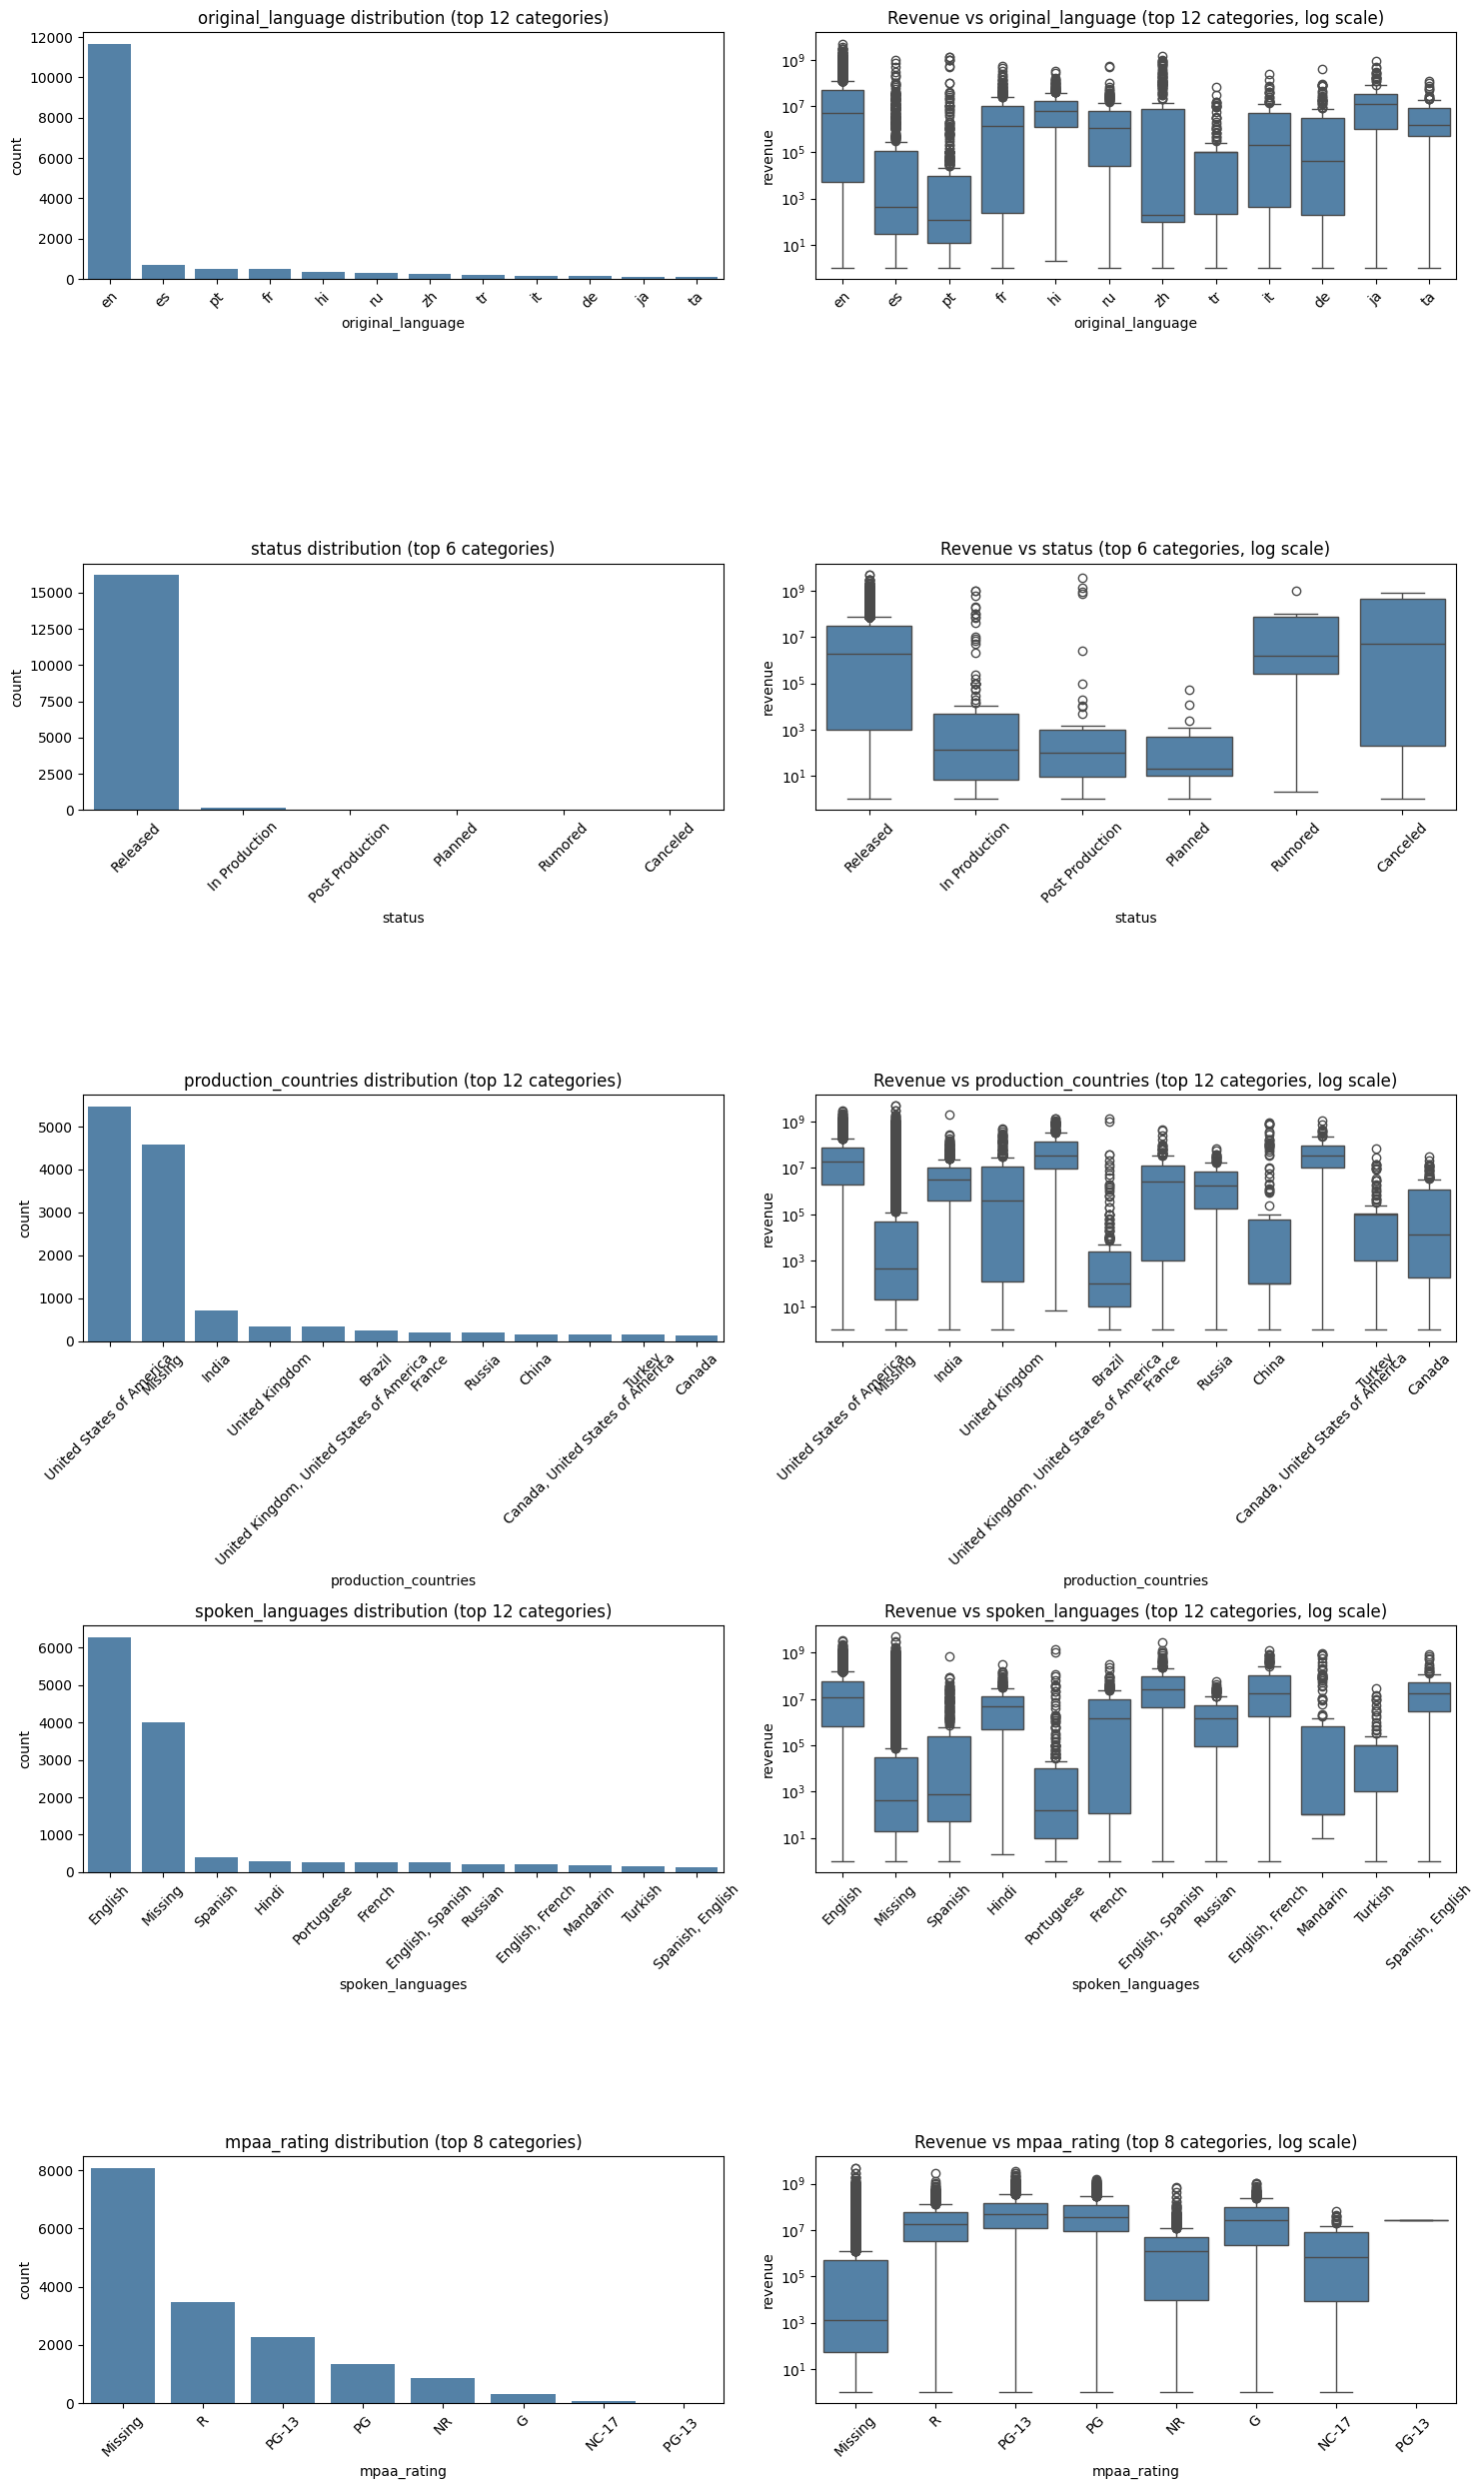

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = X[categorical_features].copy()
plot_df['revenue'] = y

max_unique_ratio = 0.10
top_n_categories = 12

boxplot_features = [
    feature
    for feature in categorical_features
    if X[feature].nunique(dropna=True) / len(X) <= max_unique_ratio
]

skipped_boxplot_features = sorted(set(categorical_features) - set(boxplot_features))

print('Categorical features available:')
print(categorical_features)
print(f"\nCategorical features selected for readable box plots (unique_ratio <= {max_unique_ratio:.2f}):")
print(boxplot_features)

if skipped_boxplot_features:
    print('\nSkipped high-cardinality categorical/text-like features:')
    display(
        categorical_cardinality.loc[
            categorical_cardinality['feature'].isin(skipped_boxplot_features),
            ['feature', 'unique_values', 'unique_ratio']
        ]
    )

if not boxplot_features:
    print('No categorical features met the readability threshold for box plots.')
else:
    n_features = len(boxplot_features)
    fig, axes = plt.subplots(n_features, 2, figsize=(15, 5 * n_features), squeeze=False)

    for i, feature in enumerate(boxplot_features):
        feature_plot_df = plot_df[[feature, 'revenue']].copy()
        feature_plot_df[feature] = feature_plot_df[feature].fillna('Missing').astype(str)

        order = feature_plot_df[feature].value_counts().head(top_n_categories).index.tolist()
        feature_plot_df = feature_plot_df[feature_plot_df[feature].isin(order)].copy()

        sns.countplot(
            data=feature_plot_df,
            x=feature,
            order=order,
            ax=axes[i, 0],
            color='steelblue'
        )
        axes[i, 0].set_title(f'{feature} distribution (top {len(order)} categories)')
        axes[i, 0].tick_params(axis='x', rotation=45)

        sns.boxplot(
            data=feature_plot_df,
            x=feature,
            y='revenue',
            order=order,
            ax=axes[i, 1],
            color='steelblue'
        )
        axes[i, 1].set_yscale('log')
        axes[i, 1].set_title(f'Revenue vs {feature} (top {len(order)} categories, log scale)')
        axes[i, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


## Histogram to study the feature distributions
#### Raw distributions before any EDA-only capping or train/test preprocessing

Raw numerical, binary, and target distributions:
         popularity        budget       runtime  actor_1_popularity  \
count  16440.000000  1.644000e+04  16440.000000        10402.000000   
mean      19.086364  1.695832e+07     80.210645            3.348436   
std      147.671674  5.439556e+07     63.928782            3.457967   
min        0.000000  1.000000e+00      0.000000            0.000000   
25%        0.600000  8.780000e+02     14.000000            0.879175   
50%        4.373000  1.800000e+06     94.000000            2.491450   
75%       15.467250  1.600000e+07    113.000000            4.726700   
max     8763.998000  5.000000e+09    999.000000           32.907700   

       actor_2_popularity  actor_3_popularity         adult       revenue  
count        10193.000000        10011.000000  15883.000000  1.644000e+04  
mean             2.544475            2.112999      0.018007  5.029277e+07  
std              2.656660            2.085150      0.132979  1.629104e+08  
min    

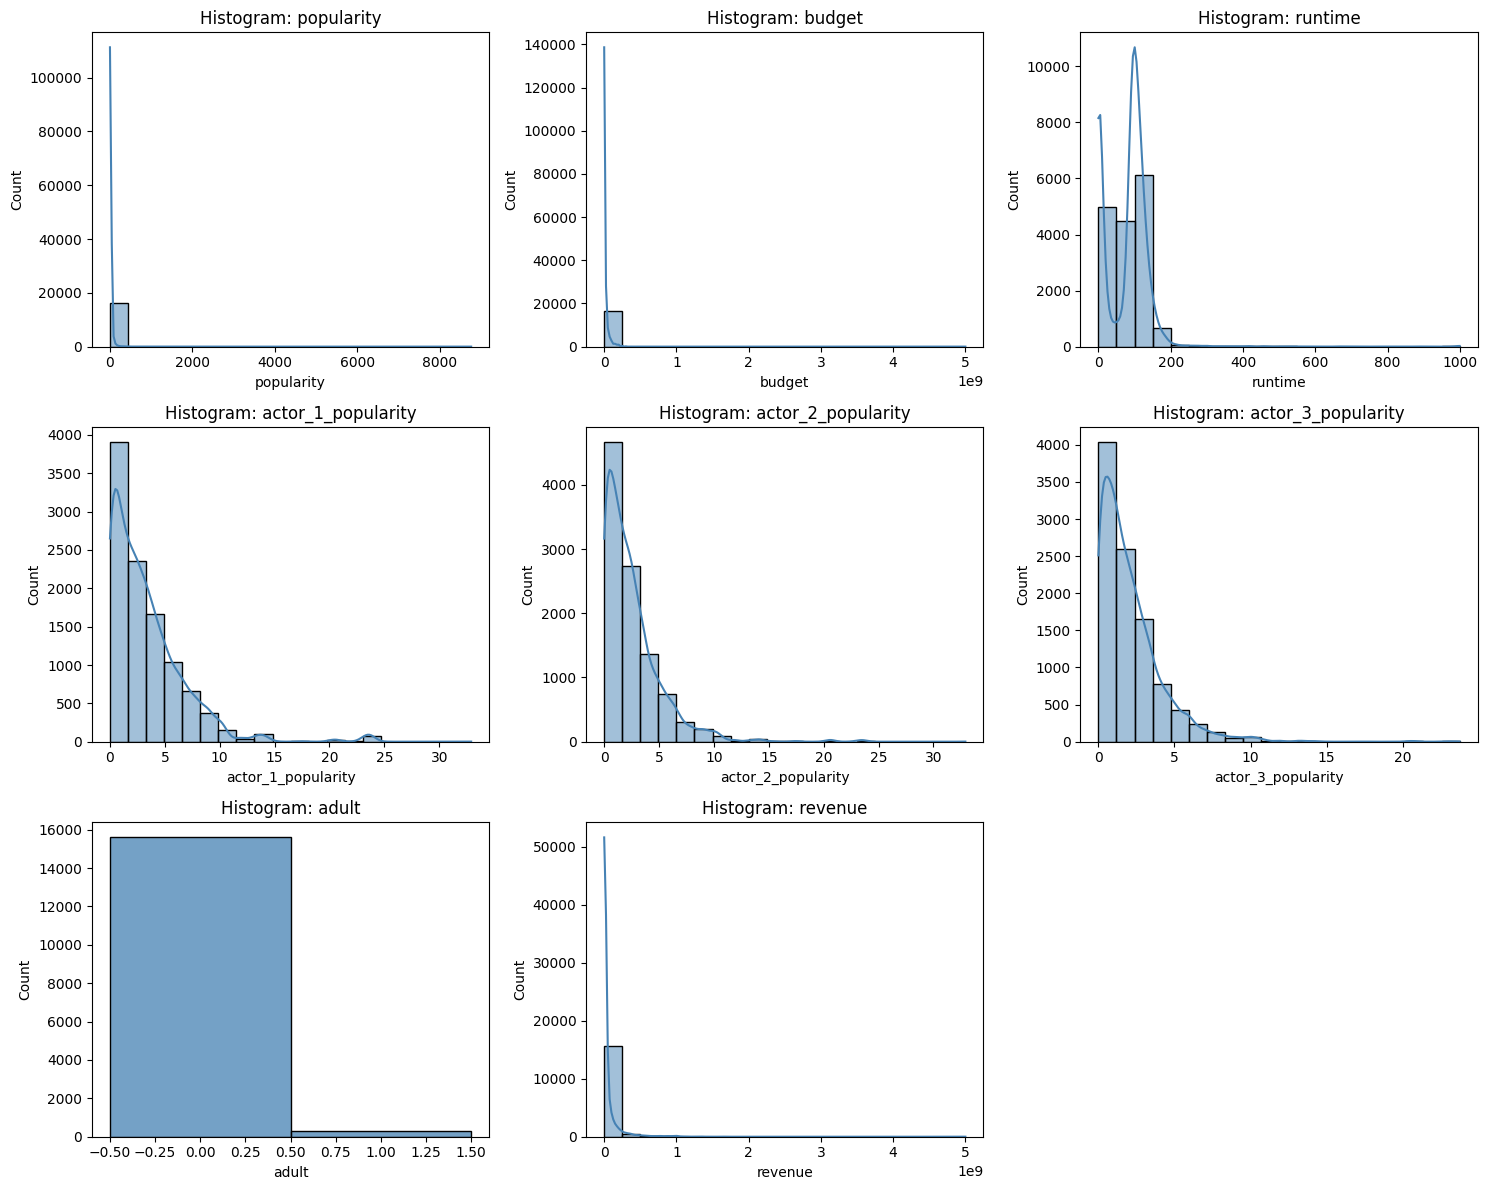

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_features = numerical_features + binary_features + ['revenue']
plot_data_raw = X[numerical_features + binary_features].copy()
plot_data_raw['revenue'] = y

print('Raw numerical, binary, and target distributions:')
print(plot_data_raw.describe())

cols = 3
rows = int(np.ceil(len(plot_features) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, feature in enumerate(plot_features):
    series = plot_data_raw[feature].dropna()
    if feature in binary_features:
        sns.histplot(series, bins=[-0.5, 0.5, 1.5], discrete=True, ax=axes[i], color='steelblue')
    else:
        sns.histplot(series, bins=20, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Histogram: {feature}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#### EDA-only view after 99.5th percentile capping on copies of the base data

,feature,cap_quantile,cap_value,applied_on
0,popularity,0.995,2.943929e+02,X_capped
1,budget,0.995,2.050000e+08,X_capped
2,runtime,0.995,2.838050e+02,X_capped
3,revenue,0.995,1.000000e+09,y_capped


Base X and y stay unchanged in this notebook. Refit these caps on the training split during modeling.

Capped numerical, binary, and target distributions:
         popularity        budget       runtime  actor_1_popularity  \
count  16440.000000  1.644000e+04  16440.000000        10402.000000   
mean      13.872674  1.614214e+07     78.898042            3.348436   
std       30.479197  3.323514e+07     53.890052            3.457967   
min        0.000000  1.000000e+00      0.000000            0.000000   
25%        0.600000  8.780000e+02     14.000000            0.879175   
50%        4.373000  1.800000e+06     94.000000            2.491450   
75%       15.467250  1.600000e+07    113.000000            4.726700   
max      294.392890  2.050000e+08    283.805000           32.907700   

       actor_2_popularity  actor_3_popularity         adult       revenue  
count        10193.000000        10011.000000  15883.000000  1.644000e+04  
mean             2.544475            2.112999      0.

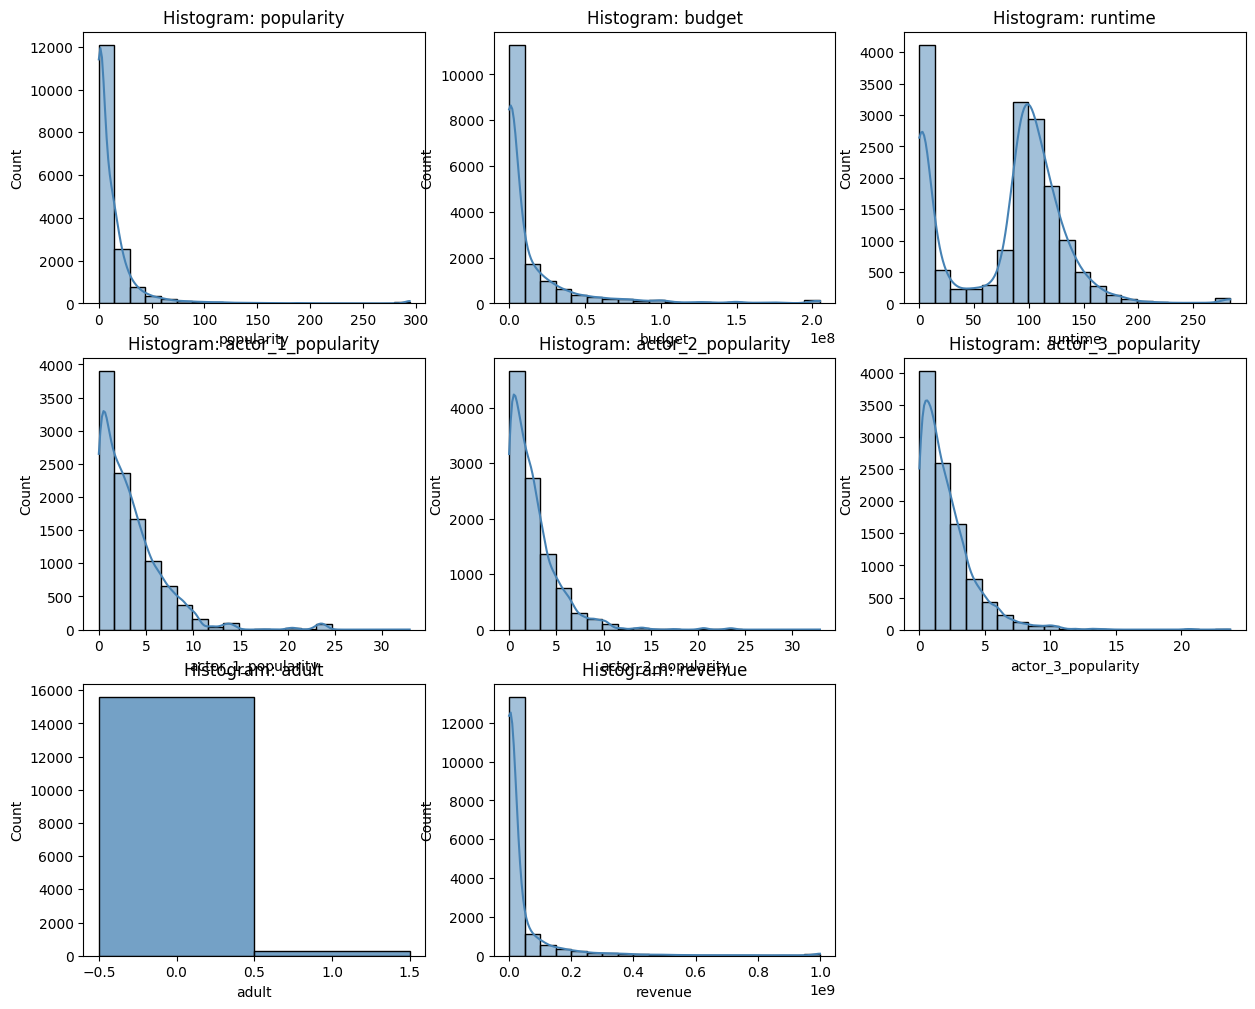

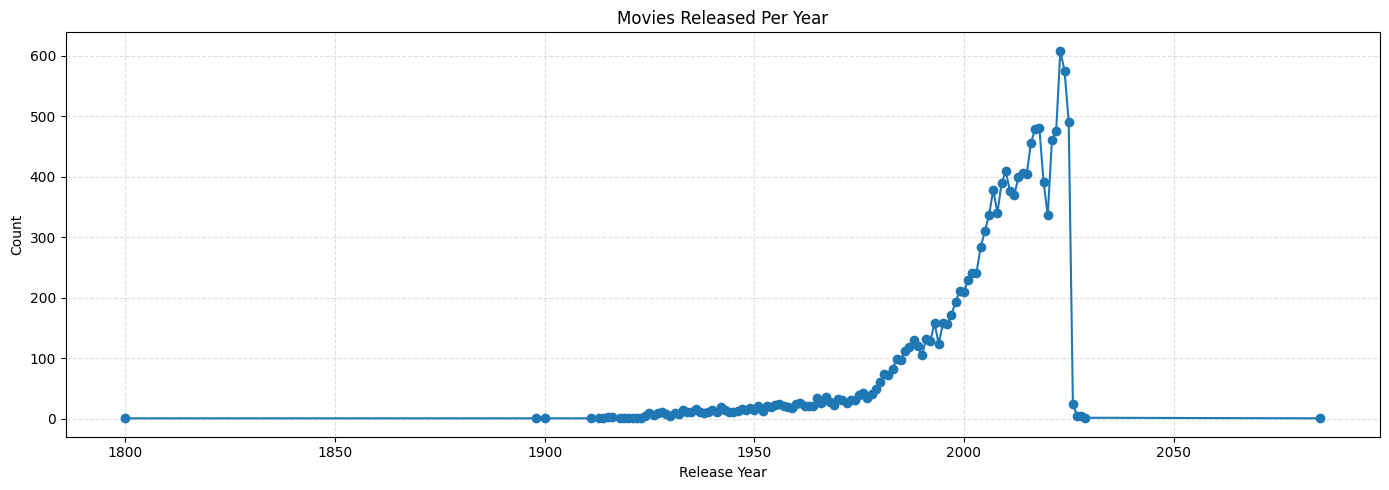

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

X_capped = X.copy()
y_capped = y.copy()
features_to_cap = ['popularity', 'budget', 'runtime']
cap_quantile = 0.995
cap_values = {}

for feature in features_to_cap:
    feature_cap = X_capped[feature].quantile(cap_quantile)
    cap_values[feature] = feature_cap
    X_capped[feature] = X_capped[feature].clip(upper=feature_cap)

revenue_cap = y_capped.quantile(cap_quantile)
y_capped = y_capped.clip(upper=revenue_cap)

cap_summary = pd.DataFrame({
    'feature': features_to_cap + ['revenue'],
    'cap_quantile': [cap_quantile] * (len(features_to_cap) + 1),
    'cap_value': [cap_values[feature] for feature in features_to_cap] + [revenue_cap],
    'applied_on': ['X_capped'] * len(features_to_cap) + ['y_capped'],
})
display(cap_summary)
print('Base X and y stay unchanged in this notebook. Refit these caps on the training split during modeling.')

plot_features = numerical_features + binary_features + ['revenue']
plot_data_capped = X_capped[numerical_features + binary_features].copy()
plot_data_capped['revenue'] = y_capped

print('\nCapped numerical, binary, and target distributions:')
print(plot_data_capped.describe())

cols = 3
rows = int(np.ceil(len(plot_features) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, feature in enumerate(plot_features):
    series = plot_data_capped[feature].dropna()
    if feature in binary_features:
        sns.histplot(series, bins=[-0.5, 0.5, 1.5], discrete=True, ax=axes[i], color='steelblue')
    else:
        sns.histplot(series, bins=20, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Histogram: {feature}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

release_dates = pd.to_datetime(X['release_date'], errors='coerce')
release_years = release_dates.dt.year.dropna()

print("Missing release dates after parsing:", release_dates.isna().sum())
print(release_years.describe())

# plt.figure(figsize=(12, 5))
# sns.histplot(release_years, bins=40, kde=True, color='steelblue')
# plt.title('Release Date Distribution')
# plt.xlabel('Release Year')
# plt.ylabel('Number of Movies')
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(14, 5))
release_years.value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Movies Released Per Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Pearson correlation coefficient between Revenue and all numerical features

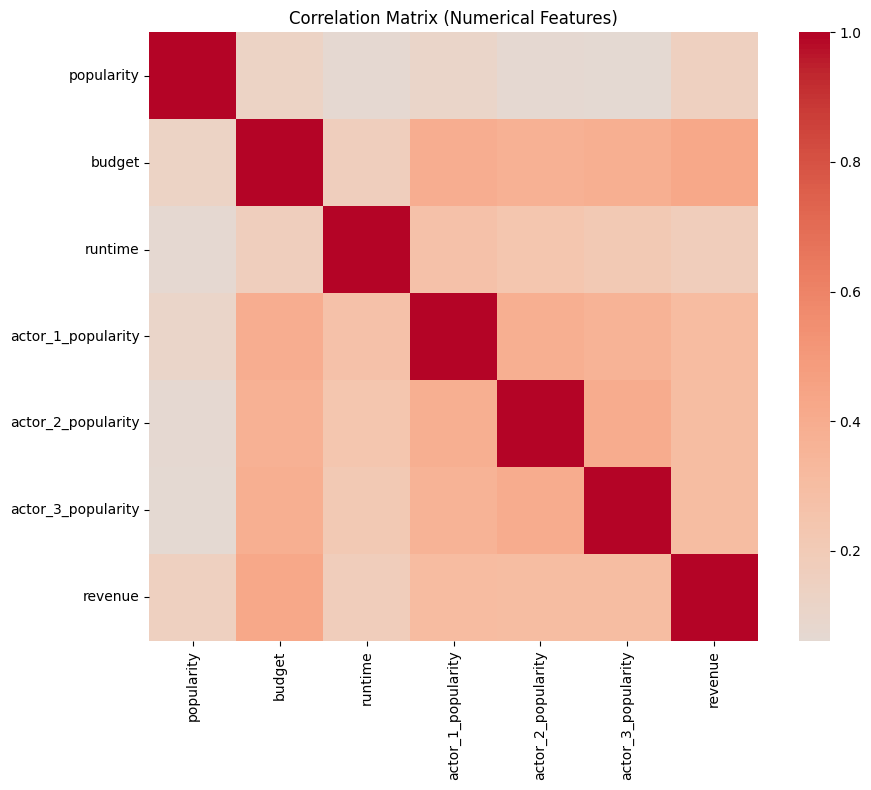

Top pairwise absolute correlations:


Loading ITables v2.7.1 from the internet... (need help?)


(j) Correlation with target (descending):


Loading ITables v2.7.1 from the internet... (need help?)


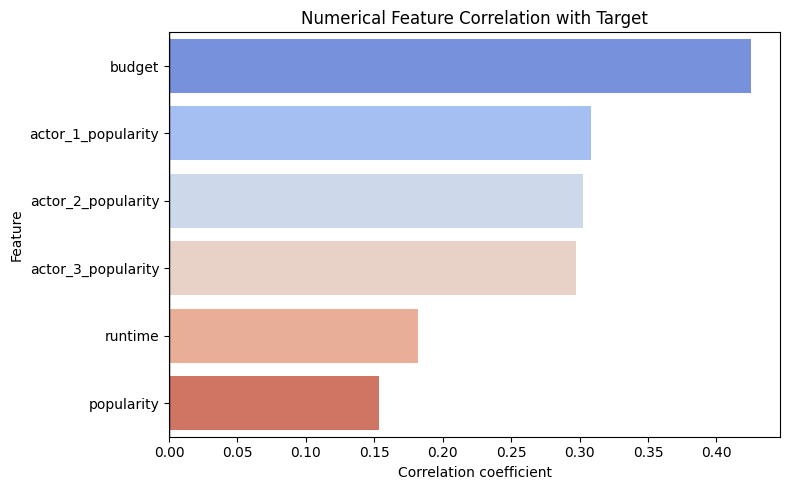

In [6]:
corr_df = X[numerical_features].copy()
corr_df["revenue"] = y

# Correlation matrix
corr_matrix = corr_df.corr()
# (i) Correlation matrix for numerical features
# corr_matrix = X[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.show()

# Show strongest absolute pairwise correlations (excluding self-correlation)

abs_corr = corr_matrix.abs()
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

top_pairs = (
    upper.unstack()
    .dropna()
    .sort_values(ascending=False)
    .head(10)
)

print('Top pairwise absolute correlations:')
show(top_pairs.to_frame('abs_correlation'))

# (j) Correlation between each numerical feature and target
num_with_target = X[numerical_features].copy()
num_with_target['target'] = y.astype(float)
target_corr = num_with_target.corr()['target'].drop('target').sort_values(ascending=False)

print('(j) Correlation with target (descending):')
show(target_corr.to_frame('corr_with_target'))

plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, dodge=False, legend=False, palette='coolwarm')
plt.axvline(0, color='black', linewidth=1)
plt.title('Numerical Feature Correlation with Target')
plt.xlabel('Correlation coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Principle Component Analysis

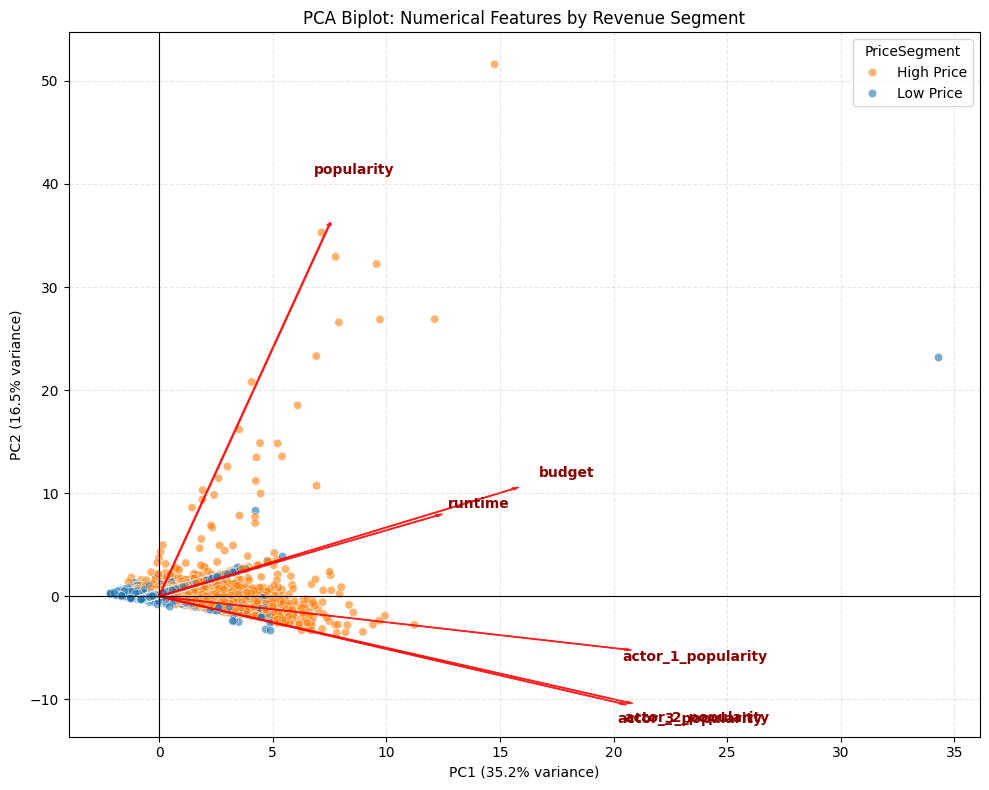

Median Revenue cutoff used for coloring: $1,749,600

--- Feature Contributions (Sorted by PC1 Impact) ---
                         PC1       PC2
actor_2_popularity  0.498432 -0.248626
actor_1_popularity  0.496637 -0.124498
actor_3_popularity  0.492002 -0.251243
budget              0.377396  0.252456
runtime             0.295942  0.189618
popularity          0.181224  0.871707


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Setup Data
# (Assumes X, y, and numerical_features are already defined in your environment)
X_num_clean = X[numerical_features].copy()
X_num_clean = X_num_clean.fillna(X_num_clean.median(numeric_only=True))

# 2. Scale Data (Crucial for valid PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num_clean)

# 3. Fit PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 4. Create DataFrame for Plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
price_cutoff = y.median()
pca_df['PriceSegment'] = np.where(y >= price_cutoff, 'High Price', 'Low Price')

# ---------------------------------------------------------
# We need to scale the arrows up so they are visible alongside the data dots.
# We'll use 80% of the maximum coordinate in the plot as a baseline.
scale_factor = np.max(np.abs(X_pca)) * 0.8
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))

# Draw the main Scatter Plot
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='PriceSegment', alpha=0.6, palette={'Low Price':'tab:blue', 'High Price':'tab:orange'})

# ---------------------------------------------------------
# Loop through every feature and draw an arrow
for i, feature in enumerate(numerical_features):
    # Get the direction (loading) for this feature
    x_dir = pca.components_[0, i]
    y_dir = pca.components_[1, i]
    
    # Draw arrow starting at (0,0)
    plt.arrow(0, 0, x_dir * scale_factor, y_dir * scale_factor,
              color='red', width=0.05, head_width=0.2, alpha=0.8)
    
    # Add text label at the tip of the arrow
    plt.text(x_dir * scale_factor * 1.15, y_dir * scale_factor * 1.15,
             feature, color='darkred', ha='center', va='center', 
             fontweight='bold')
# ---------------------------------------------------------

plt.title('PCA Biplot: Numerical Features by Revenue Segment')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True, linestyle='--', alpha=0.3) # Adds a subtle grid
plt.axhline(0, color='black', linewidth=0.8) # Adds a center line (x-axis)
plt.axvline(0, color='black', linewidth=0.8) # Adds a center line (y-axis)
plt.tight_layout()
plt.show()
print(f"Median Revenue cutoff used for coloring: ${price_cutoff:,.0f}")

# ---------------------------------------------------------
# Show which features heavily influence PC1 (The Separator)
loadings_df = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=numerical_features)
print("\n--- Feature Contributions (Sorted by PC1 Impact) ---")
# Sorting by absolute value to see the strongest features (positive or negative)
print(loadings_df.reindex(loadings_df.abs().sort_values(by='PC1', ascending=False).index))

## Missing Values

In [8]:
try:
    from itables import show
except Exception:
    show = display

reference_date = pd.Timestamp('2026-04-05')
release_year = X['release_date'].dt.year
validation_summary = pd.DataFrame({
    'check': [
        'rows_removed_during_validation',
        'duplicate_rows_remaining',
        'duplicate_title_release_date_remaining',
        'release_date_missing_after_parse',
        'release_date_before_1900-01-01',
        'release_date_after_2026-04-05',
    ],
    'count': [
        len(df_raw) - len(df_clean),
        int(df_clean.duplicated().sum()),
        int(df_clean.duplicated(subset=['title', 'release_date']).sum()),
        int(X['release_date'].isna().sum()),
        int((X['release_date'] < pd.Timestamp('1900-01-01')).sum()),
        int((X['release_date'] > reference_date).sum()),
    ],
})
print('Validation summary:')
display(validation_summary)

# Check for missing values
missing_values = X.isnull().sum().reset_index()
missing_values.columns = ['Feature', 'Missing Count']
missing_values['Missing Ratio (%)'] = (missing_values['Missing Count'] / len(X)) * 100

def get_feature_type(feature):
    if feature in numerical_features:
        return 'Numerical'
    if feature in binary_features:
        return 'Binary'
    if feature in nominal_features:
        return 'Categorical (Nominal)'
    if feature in categorical_features:
        return 'Categorical (Ordinal)'
    return 'Unknown'

missing_values['Feature Type'] = missing_values['Feature'].apply(get_feature_type)
missing_values = missing_values.sort_values(by='Missing Count', ascending=False).reset_index(drop=True)

print('\nMissing-value summary:')
if show is not None:
    show(missing_values)
else:
    display(missing_values)

numeric_like_features = numerical_features + binary_features
feature_notes = {
    'popularity': 'Strong right tail; safe to cap on train-fit copies, not in-place.',
    'budget': 'Long right tail; tiny positive values may still deserve a manual data audit.',
    'runtime': 'Many 0 values likely mean missing/invalid runtime rather than true 0 minutes.',
    'adult': 'Binary flag; mode imputation and no scaling are usually best.',
    'actor_1_popularity': 'High missingness; add a missingness flag if you impute.',
    'actor_2_popularity': 'High missingness; add a missingness flag if you impute.',
    'actor_3_popularity': 'High missingness; add a missingness flag if you impute.',
}

numeric_alerts = pd.DataFrame({
    'feature': numeric_like_features,
    'missing_count': [int(pd.to_numeric(X[c], errors='coerce').isna().sum()) for c in numeric_like_features],
    'zero_count': [int((pd.to_numeric(X[c], errors='coerce') == 0).sum()) for c in numeric_like_features],
    'negative_count': [int((pd.to_numeric(X[c], errors='coerce') < 0).sum()) for c in numeric_like_features],
    'p99_5': [float(pd.to_numeric(X[c], errors='coerce').quantile(0.995)) for c in numeric_like_features],
    'max': [float(pd.to_numeric(X[c], errors='coerce').max()) for c in numeric_like_features],
    'note': [feature_notes.get(c, '') for c in numeric_like_features],
}).sort_values(['missing_count', 'zero_count'], ascending=False)

print('\nNumeric/binary diagnostics:')
display(numeric_alerts)

print(f"Total missing values in feature set: {int(X.isnull().sum().sum())}")


Validation summary:


,check,count
0,rows_removed_during_validation,1
1,duplicate_rows_remaining,0
2,duplicate_title_release_date_remaining,0
3,release_date_missing_after_parse,2661
4,release_date_before_1900-01-01,2
5,release_date_after_2026-04-05,25



Missing-value summary:


Loading ITables v2.7.1 from the internet... (need help?)



Numeric/binary diagnostics:


,feature,missing_count,zero_count,negative_count,p99_5,max,note
5,actor_3_popularity,6429,176,0,1.047440e+01,2.374110e+01,High missingness; add a missingness flag if yo...
4,actor_2_popularity,6247,211,0,1.464120e+01,3.290770e+01,High missingness; add a missingness flag if yo...
3,actor_1_popularity,6038,284,0,2.357820e+01,3.290770e+01,High missingness; add a missingness flag if yo...
6,adult,557,15597,0,1.000000e+00,1.000000e+00,Binary flag; mode imputation and no scaling ar...
2,runtime,0,2333,0,2.838050e+02,9.990000e+02,Many 0 values likely mean missing/invalid runt...
0,popularity,0,1653,0,2.943929e+02,8.763998e+03,Strong right tail; safe to cap on train-fit co...
1,budget,0,0,0,2.050000e+08,5.000000e+09,Long right tail; tiny positive values may stil...


Total missing values in feature set: 57675


#### Imputation : Handling Missing Values [Numerical]
##### For actor's popularity, considered it to be zero as the default
##### For adult, considered it to be a non adult film as the default

In [9]:
X[['actor_1_popularity', 'actor_2_popularity', 'actor_3_popularity']] = X[['actor_1_popularity', 'actor_2_popularity', 'actor_3_popularity']].fillna(0)
X['adult'] = X['adult'].fillna(0)


In [10]:
try:
    from itables import show
except Exception:
    show = display

reference_date = pd.Timestamp('2026-04-05')
release_year = X['release_date'].dt.year
validation_summary = pd.DataFrame({
    'check': [
        'rows_removed_during_validation',
        'duplicate_rows_remaining',
        'duplicate_title_release_date_remaining',
        'release_date_missing_after_parse',
        'release_date_before_1900-01-01',
        'release_date_after_2026-04-05',
    ],
    'count': [
        len(df_raw) - len(df_clean),
        int(df_clean.duplicated().sum()),
        int(df_clean.duplicated(subset=['title', 'release_date']).sum()),
        int(X['release_date'].isna().sum()),
        int((X['release_date'] < pd.Timestamp('1900-01-01')).sum()),
        int((X['release_date'] > reference_date).sum()),
    ],
})
print('Validation summary:')
display(validation_summary)

# Check for missing values
missing_values = X.isnull().sum().reset_index()
missing_values.columns = ['Feature', 'Missing Count']
missing_values['Missing Ratio (%)'] = (missing_values['Missing Count'] / len(X)) * 100

def get_feature_type(feature):
    if feature in numerical_features:
        return 'Numerical'
    if feature in binary_features:
        return 'Binary'
    if feature in nominal_features:
        return 'Categorical (Nominal)'
    if feature in categorical_features:
        return 'Categorical (Ordinal)'
    return 'Unknown'

missing_values['Feature Type'] = missing_values['Feature'].apply(get_feature_type)
missing_values = missing_values.sort_values(by='Missing Count', ascending=False).reset_index(drop=True)

print('\nMissing-value summary:')
if show is not None:
    show(missing_values)
else:
    display(missing_values)

numeric_like_features = numerical_features + binary_features

numeric_alerts = pd.DataFrame({
    'feature': numeric_like_features,
    'missing_count': [int(pd.to_numeric(X[c], errors='coerce').isna().sum()) for c in numeric_like_features],
    'zero_count': [int((pd.to_numeric(X[c], errors='coerce') == 0).sum()) for c in numeric_like_features],
    'negative_count': [int((pd.to_numeric(X[c], errors='coerce') < 0).sum()) for c in numeric_like_features],
    'p99_5': [float(pd.to_numeric(X[c], errors='coerce').quantile(0.995)) for c in numeric_like_features],
    'max': [float(pd.to_numeric(X[c], errors='coerce').max()) for c in numeric_like_features],
}).sort_values(['missing_count', 'zero_count'], ascending=False)

print('\nNumeric/binary diagnostics:')
display(numeric_alerts)

print(f"Total missing values in feature set: {int(X.isnull().sum().sum())}")


Validation summary:


,check,count
0,rows_removed_during_validation,1
1,duplicate_rows_remaining,0
2,duplicate_title_release_date_remaining,0
3,release_date_missing_after_parse,2661
4,release_date_before_1900-01-01,2
5,release_date_after_2026-04-05,25



Missing-value summary:


Loading ITables v2.7.1 from the internet... (need help?)



Numeric/binary diagnostics:


,feature,missing_count,zero_count,negative_count,p99_5,max
6,adult,0,16154,0,1.000000e+00,1.000000e+00
5,actor_3_popularity,0,6605,0,1.003285e+01,2.374110e+01
4,actor_2_popularity,0,6458,0,1.296714e+01,3.290770e+01
3,actor_1_popularity,0,6322,0,2.240762e+01,3.290770e+01
2,runtime,0,2333,0,2.838050e+02,9.990000e+02
0,popularity,0,1653,0,2.943929e+02,8.763998e+03
1,budget,0,0,0,2.050000e+08,5.000000e+09


Total missing values in feature set: 38404


### original_language, mpaa_rating - Planned to fill the missing values with mode and do One Hot Encoding

In [11]:
import pandas as pd

fill_values = {
    'mpaa_rating': 'G',
    'tagline': 'null',
    'keywords': 'null',
    'production_countries': 'null',
    'production_companies': 'null',
    'spoken_languages': 'null',
    'genres': 'null',
    'overview': 'null',
}

cols_to_fill = list(fill_values.keys())
X.loc[:, cols_to_fill] = X[cols_to_fill].fillna(fill_values)

X['release_date'] = pd.to_datetime(X['release_date'], errors='coerce')
mean_release_date = X['release_date'].dropna().mean()

if pd.notna(mean_release_date):
    X['release_date'] = X['release_date'].fillna(mean_release_date.floor('D'))

try:
    from itables import show
except Exception:
    show = None

numerical_features = globals().get('numerical_features', [])
binary_features = globals().get('binary_features', [])
nominal_features = globals().get('nominal_features', [])
categorical_features = globals().get('categorical_features', [])

missing_values = X.isnull().sum().reset_index()
missing_values.columns = ['Feature', 'Missing Count']
missing_values['Missing Ratio (%)'] = (missing_values['Missing Count'] / len(X)) * 100

def get_feature_type(feature):
    if feature in numerical_features:
        return 'Numerical'
    if feature in binary_features:
        return 'Binary'
    if feature in nominal_features:
        return 'Categorical (Nominal)'
    if feature in categorical_features:
        return 'Categorical (Ordinal)'
    return 'Unknown'

missing_values['Feature Type'] = missing_values['Feature'].apply(get_feature_type)
missing_values = missing_values.sort_values(by='Missing Count', ascending=False).reset_index(drop=True)

print('\nMissing-value summary:')
if show is not None:
    show(missing_values)
else:
    display(missing_values)

print(f"Total missing values in feature set: {int(X.isnull().sum().sum())}")



Missing-value summary:


Loading ITables v2.7.1 from the internet... (need help?)


Total missing values in feature set: 0


In [12]:
from pathlib import Path

ml_ready_df = X.copy()
ml_ready_df['revenue'] = y

if pd.api.types.is_datetime64_any_dtype(ml_ready_df['release_date']):
    ml_ready_df['release_date'] = ml_ready_df['release_date'].dt.strftime('%Y-%m-%d')

output_dir = Path(r"Dataset\comparison_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "Movies-Dataset-no-missing-2000-2026-ML-Ready.csv"
ml_ready_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Saved file: {output_path}")
print(f"Shape: {ml_ready_df.shape}")
print(f"Total missing values: {int(ml_ready_df.isnull().sum().sum())}")

Saved file: Dataset\comparison_outputs\Movies-Dataset-no-missing-2000-2026-ML-Ready.csv
Shape: (16440, 20)
Total missing values: 0
